Customer churn is a fundamental problem in the telecom industry. It occurs when customers decide to leave the company’s services because they feel that the services no longer meet their needs or expectations.

To address this issue, we aim to use predictive analysis to identify customers who are likely to churn before they actually leave. This allows the company to take proactive actions, such as offering personalized deals or improving service quality, in order to retain these customers.

In the telecom industry, churn is a critical concern because acquiring new customers is significantly more expensive than retaining existing ones.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Setting
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')

print('Libraries loaded successfully!')

Libraries loaded successfully!


In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/RaniaMofeed/Customer-Churn-Prediction/refs/heads/main/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f'Dataset shape: {df.shape}')
print(f'Rows: {df.shape[0]:,}')
print(f'Columns: {df.shape[1]}')
df.head()

Dataset shape: (7043, 21)
Rows: 7,043
Columns: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [9]:
df.info()
print('\n--- unique values in every coulums ---')
print(f"{'num':<5} {'column name':<20} {'unique values'}")
print("-" * 50)

for num, col in enumerate(df.columns):
    print(f"{num:<5} {col:<20} {df[col].nunique()} unique values")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


=== Churn Distribution ===
No: 5,174 customers (73.5%)
Yes: 1,869 customers (26.5%)


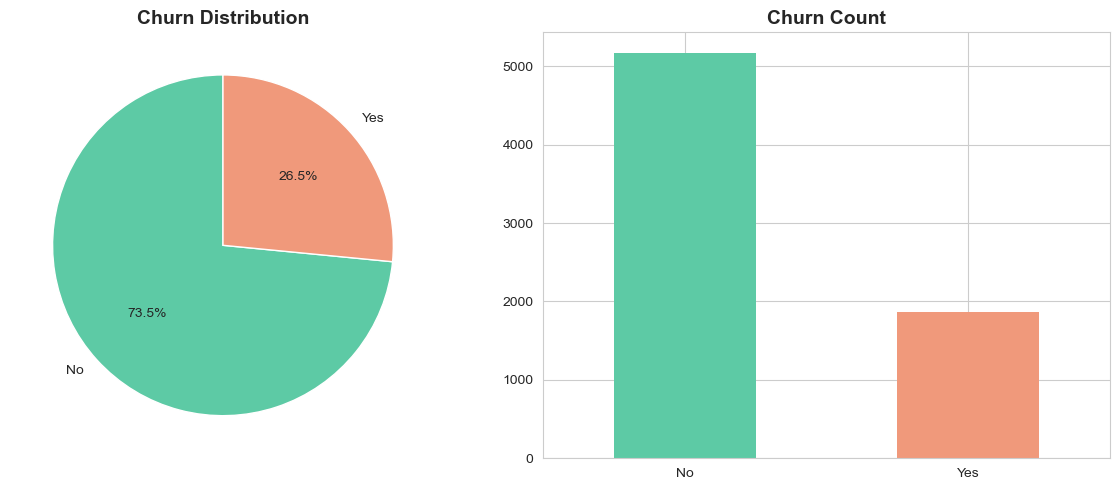

Plot saved!


In [18]:
# How Many customers leave ,and stay 
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print('=== Churn Distribution ===')
for val in churn_counts.index:
    print(f'{val}: {churn_counts[val]:,} customers ({churn_pct[val]:.1f}%)')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%',
            colors=['#5DCAA5', '#F0997B'], startangle=90)
axes[0].set_title('Churn Distribution', fontsize=14, fontweight='bold')

churn_counts.plot(kind='bar', ax=axes[1], color=['#5DCAA5', '#F0997B'], edgecolor='none')
axes[1].set_title('Churn Count', fontsize=14, fontweight='bold')
axes[1].set_xlabel('')
axes[1].tick_params(rotation=0)

plt.tight_layout()
plt.savefig('churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved!')

In [21]:
print('=== Missing Values ===')
print(df.isnull().sum()[df.isnull().sum() > 0])

=== Missing Values ===
Series([], dtype: int64)


In [22]:
print('\n=== TotalCharges sample ===')
print(df['TotalCharges'].dtype)
print(df['TotalCharges'].head(10))


=== TotalCharges sample ===
object
0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
5      820.5
6     1949.4
7      301.9
8    3046.05
9    3487.95
Name: TotalCharges, dtype: object


In [23]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
null_total = df['TotalCharges'].isnull().sum()
print(f'Rows with missing TotalCharges: {null_total}')

Rows with missing TotalCharges: 11


In [24]:
print(df[df['TotalCharges'].isnull()][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']])

      customerID  tenure  MonthlyCharges  TotalCharges
488   4472-LVYGI       0           52.55           NaN
753   3115-CZMZD       0           20.25           NaN
936   5709-LVOEQ       0           80.85           NaN
1082  4367-NUYAO       0           25.75           NaN
1340  1371-DWPAZ       0           56.05           NaN
3331  7644-OMVMY       0           19.85           NaN
3826  3213-VVOLG       0           25.35           NaN
4380  2520-SGTTA       0           20.00           NaN
5218  2923-ARZLG       0           19.70           NaN
6670  4075-WKNIU       0           73.35           NaN
6754  2775-SEFEE       0           61.90           NaN


In [29]:
df['TotalCharges'].isnull().sum()

np.int64(11)

In [30]:
df = df.dropna(subset=['TotalCharges'])

In [31]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [32]:
 df = df.drop('customerID', axis=1)

In [33]:
print(f'Clean dataset shape: {df.shape}')
print(f'\nChurn column after mapping:')
print(df['Churn'].value_counts())
print(f'\nAny nulls left? {df.isnull().sum().sum()}')

Clean dataset shape: (7032, 20)

Churn column after mapping:
Churn
0    5163
1    1869
Name: count, dtype: int64

Any nulls left? 0


In [34]:
print(df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe().round(2))

        tenure  MonthlyCharges  TotalCharges
count  7032.00         7032.00       7032.00
mean     32.42           64.80       2283.30
std      24.55           30.09       2266.77
min       1.00           18.25         18.80
25%       9.00           35.59        401.45
50%      29.00           70.35       1397.48
75%      55.00           89.86       3794.74
max      72.00          118.75       8684.80


In [37]:
print('\n=== Categorical Columns ===')
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    print(f"Column: {col}")
    print(f"Unique values: {df[col].unique()}")


=== Categorical Columns ===
Column: gender
Unique values: ['Female' 'Male']
Column: Partner
Unique values: ['Yes' 'No']
Column: Dependents
Unique values: ['No' 'Yes']
Column: PhoneService
Unique values: ['No' 'Yes']
Column: MultipleLines
Unique values: ['No phone service' 'No' 'Yes']
Column: InternetService
Unique values: ['DSL' 'Fiber optic' 'No']
Column: OnlineSecurity
Unique values: ['No' 'Yes' 'No internet service']
Column: OnlineBackup
Unique values: ['Yes' 'No' 'No internet service']
Column: DeviceProtection
Unique values: ['No' 'Yes' 'No internet service']
Column: TechSupport
Unique values: ['No' 'Yes' 'No internet service']
Column: StreamingTV
Unique values: ['No' 'Yes' 'No internet service']
Column: StreamingMovies
Unique values: ['No' 'Yes' 'No internet service']
Column: Contract
Unique values: ['Month-to-month' 'One year' 'Two year']
Column: PaperlessBilling
Unique values: ['Yes' 'No']
Column: PaymentMethod
Unique values: ['Electronic check' 'Mailed check' 'Bank transfer (a

In [39]:
df['TotalCharges'].isnull().sum()

np.int64(0)

>Does the type of contract affect the decision to leave?

In [42]:
contract_churn = df.groupby('Contract')['Churn'].mean() * 100
print(contract_churn)

Contract
Month-to-month    42.709677
One year          11.277174
Two year           2.848665
Name: Churn, dtype: float64


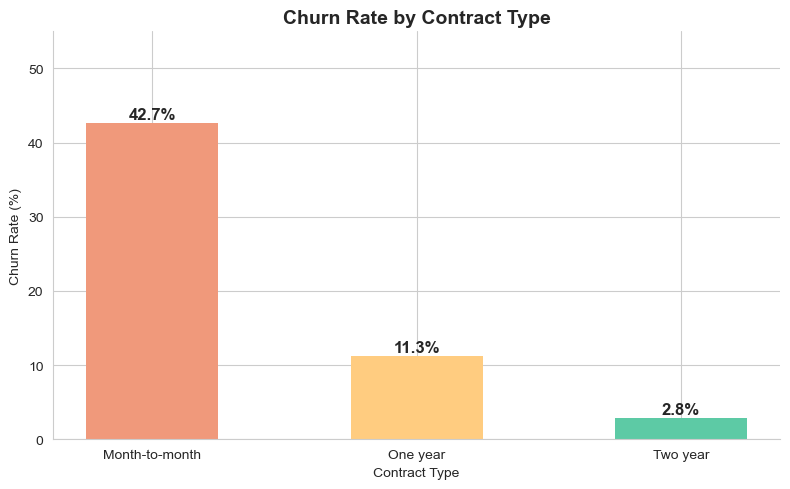

In [43]:
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(contract_churn.index, contract_churn.values,
               color=['#F0997B', '#FFCC80', '#5DCAA5'], edgecolor='none', width=0.5)

for bar, val in zip(bars, contract_churn.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')

ax.set_title('Churn Rate by Contract Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Contract Type'); ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, 55); sns.despine()
plt.tight_layout()
plt.savefig('churn_by_contract.png', dpi=150, bbox_inches='tight')
plt.show()

>Do new customers leave more than long-term customers?

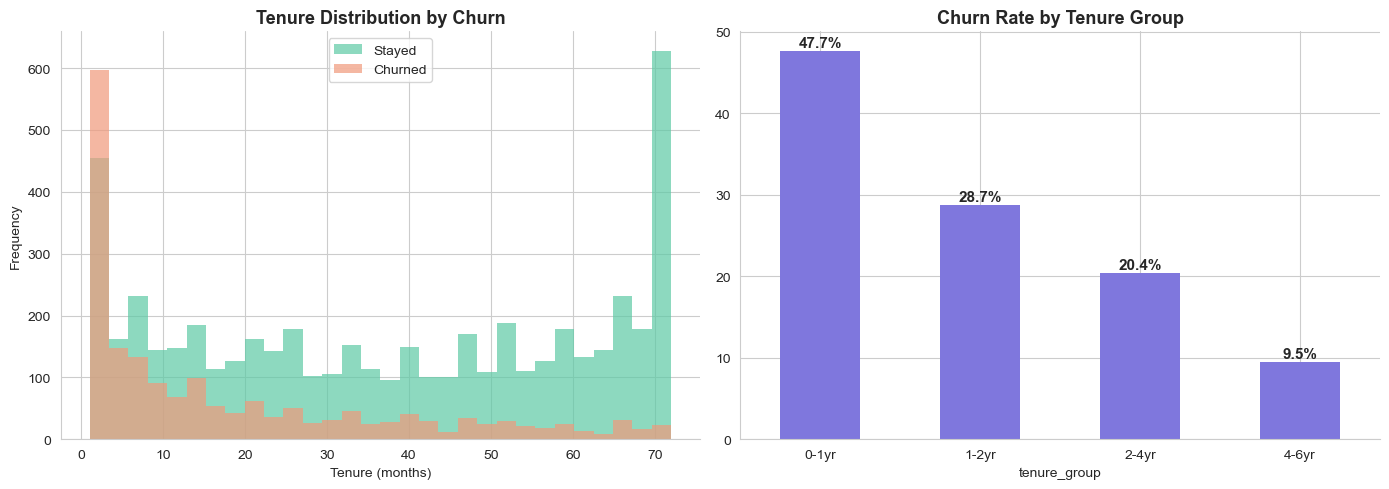

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution
df[df['Churn']==0]['tenure'].plot(kind='hist', ax=axes[0], bins=30,
    alpha=0.7, color='#5DCAA5', label='Stayed', edgecolor='none')
df[df['Churn']==1]['tenure'].plot(kind='hist', ax=axes[0], bins=30,
    alpha=0.7, color='#F0997B', label='Churned', edgecolor='none')
axes[0].set_title('Tenure Distribution by Churn', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Tenure (months)'); axes[0].legend()
sns.despine(ax=axes[0])

# Tenure groups
df['tenure_group'] = pd.cut(df['tenure'], bins=[0,12,24,48,72],
                             labels=['0-1yr', '1-2yr', '2-4yr', '4-6yr'])
tenure_churn = df.groupby('tenure_group', observed=True)['Churn'].mean() * 100
tenure_churn.plot(kind='bar', ax=axes[1], color='#7F77DD', edgecolor='none', width=0.5)

for i, val in enumerate(tenure_churn.values):
    axes[1].text(i, val + 0.5, f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')

axes[1].set_title('Churn Rate by Tenure Group', fontsize=13, fontweight='bold')
axes[1].tick_params(rotation=0); sns.despine(ax=axes[1])
plt.tight_layout()
plt.savefig('churn_by_tenure.png', dpi=150, bbox_inches='tight')
plt.show()

>Monthly Charges vs Churn

C:\Users\Rania\AppData\Local\Temp\ipykernel_11280\1461293170.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Stayed', 'Churned'])


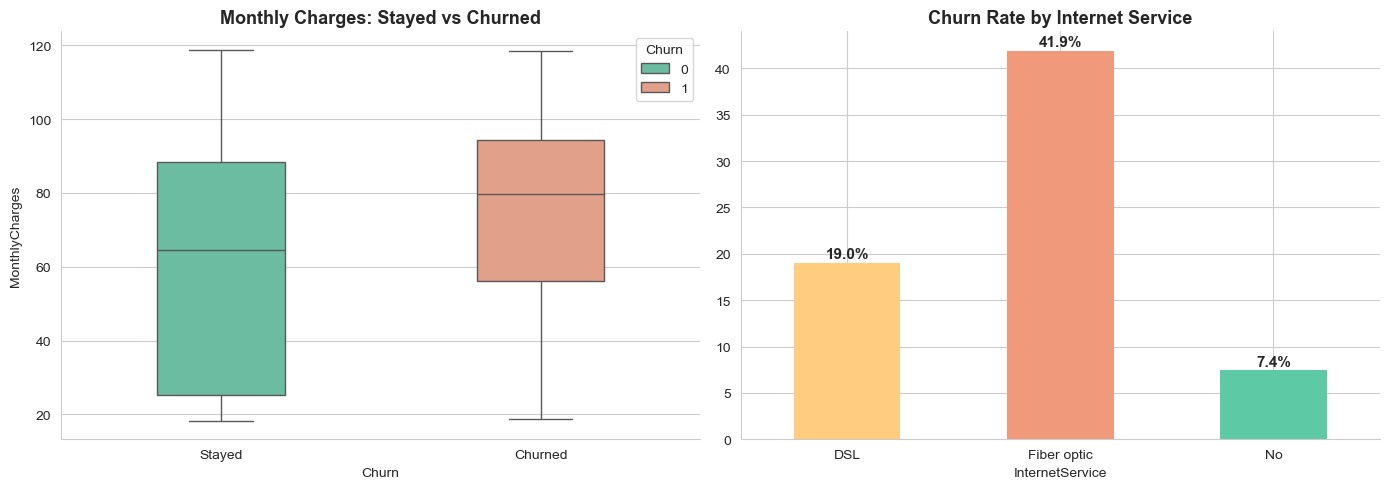

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='Churn', y='MonthlyCharges', hue='Churn',
            palette={0: '#5DCAA5', 1: '#F0997B'}, ax=axes[0], width=0.4)
axes[0].set_xticklabels(['Stayed', 'Churned'])
axes[0].set_title('Monthly Charges: Stayed vs Churned', fontsize=13, fontweight='bold')
sns.despine(ax=axes[0])

internet_churn = df.groupby('InternetService')['Churn'].mean() * 100
internet_churn.plot(kind='bar', ax=axes[1],
    color=['#FFCC80', '#F0997B', '#5DCAA5'], edgecolor='none', width=0.5)

for i, val in enumerate(internet_churn.values):
    axes[1].text(i, val + 0.5, f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')

axes[1].set_title('Churn Rate by Internet Service', fontsize=13, fontweight='bold')
axes[1].tick_params(rotation=0); sns.despine(ax=axes[1])
plt.tight_layout()
plt.savefig('churn_by_charges.png', dpi=150, bbox_inches='tight')
plt.show()

>  Correlation Heatmap

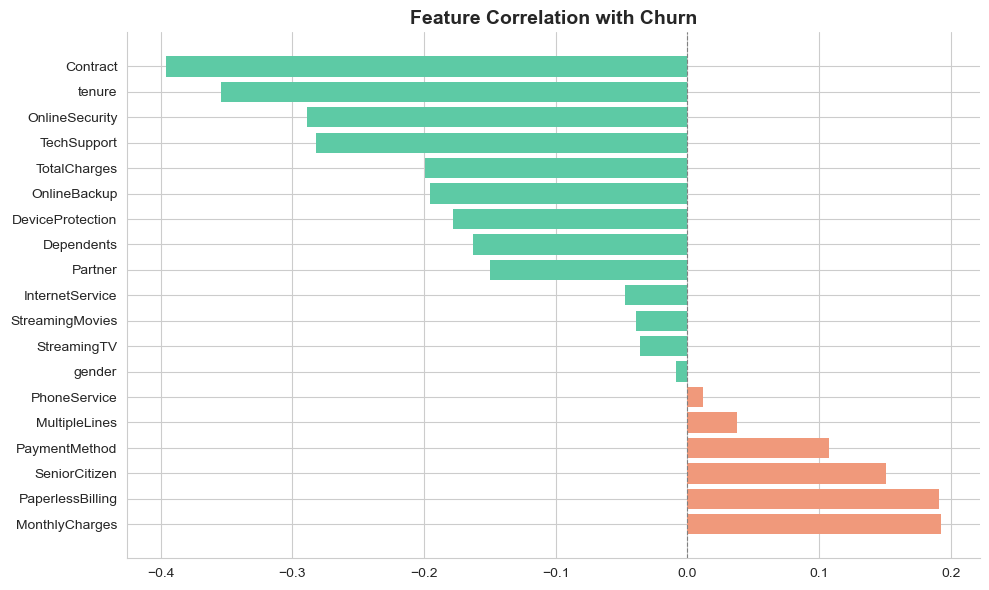

Top factors INCREASING churn:
MonthlyCharges      0.192858
PaperlessBilling    0.191454
SeniorCitizen       0.150541
PaymentMethod       0.107852
MultipleLines       0.038043
Name: Churn, dtype: float64

Top factors DECREASING churn:
gender            -0.008545
StreamingTV       -0.036303
StreamingMovies   -0.038802
InternetService   -0.047097
Partner           -0.149982
Name: Churn, dtype: float64


In [46]:
df_encoded = df.copy()
cat_cols = df_encoded.select_dtypes(include='object').columns
for col in cat_cols:
    df_encoded[col] = pd.Categorical(df_encoded[col]).codes

if 'tenure_group' in df_encoded.columns:
    df_encoded = df_encoded.drop('tenure_group', axis=1)

churn_corr = df_encoded.corr()['Churn'].sort_values(ascending=False).drop('Churn')

plt.figure(figsize=(10, 6))
colors = ['#F0997B' if x > 0 else '#5DCAA5' for x in churn_corr.values]
plt.barh(churn_corr.index, churn_corr.values, color=colors, edgecolor='none')
plt.axvline(x=0, color='gray', linewidth=0.8, linestyle='--')
plt.title('Feature Correlation with Churn', fontsize=14, fontweight='bold')
sns.despine(); plt.tight_layout()
plt.savefig('churn_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top factors INCREASING churn:')
print(churn_corr[churn_corr > 0].head(5))
print('\nTop factors DECREASING churn:')
print(churn_corr[churn_corr < 0].head(5))

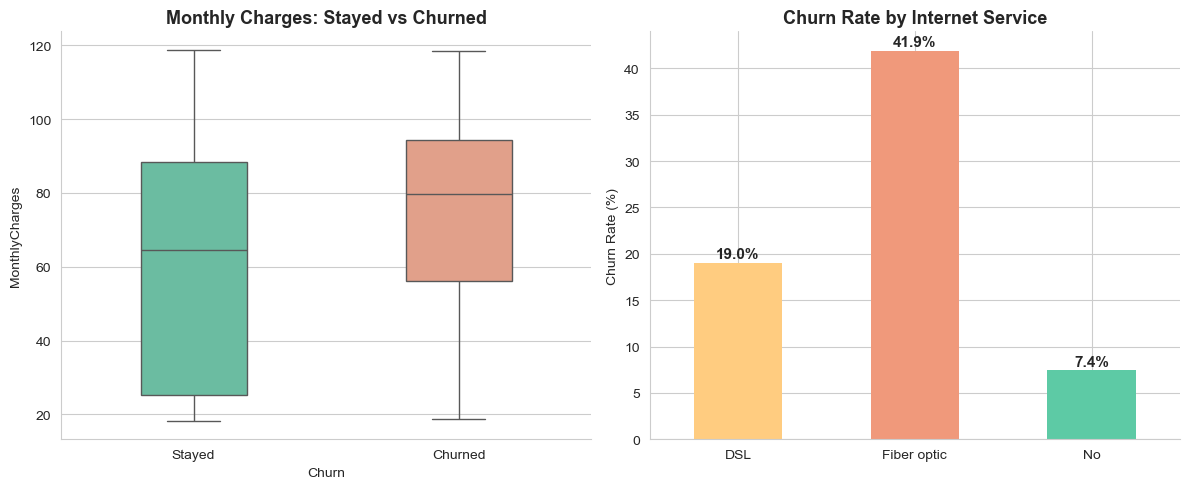

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

# 🔹 تحويل Churn لأسماء واضحة (أفضل من set_xticklabels)
df['Churn'] = df['Churn'].map({0: 'Stayed', 1: 'Churned'})

# 🔹 إنشاء الشكل (2 رسومات جنب بعض)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# =========================
# 📊 1. Boxplot
# =========================
sns.boxplot(
    data=df,
    x='Churn',
    y='MonthlyCharges',
    hue='Churn',  # مطلوب عشان palette
    palette={'Stayed': '#5DCAA5', 'Churned': '#F0997B'},
    ax=axes[0],
    width=0.4,
    legend=False
)

axes[0].set_title('Monthly Charges: Stayed vs Churned',
                  fontsize=13, fontweight='bold')

sns.despine(ax=axes[0])

# =========================
# 📊 2. Bar Chart
# =========================
internet_churn = (
    df.groupby('InternetService')['Churn']
    .apply(lambda x: (x == 'Churned').mean() * 100)
    .round(2)
)

internet_churn.plot(
    kind='bar',
    ax=axes[1],
    color=['#FFCC80', '#F0997B', '#5DCAA5'],
    edgecolor='none',
    width=0.5
)

# 🔹 كتابة النسب فوق الأعمدة
for i, val in enumerate(internet_churn.values):
    axes[1].text(i, val + 0.5, f'{val:.1f}%',
                 ha='center', fontsize=11, fontweight='bold')

axes[1].set_title('Churn Rate by Internet Service',
                  fontsize=13, fontweight='bold')

axes[1].set_xlabel('')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].tick_params(rotation=0)

sns.despine(ax=axes[1])

# =========================
# 🧩 تحسين الشكل
# =========================
plt.tight_layout()

# 💾 حفظ الصورة
plt.savefig('churn_by_charges.png', dpi=150, bbox_inches='tight')

# 👀 عرض الرسم
plt.show()